In [ ]:
# using Pkg
# Pkg.activate("/home/jek354/research/ML-signproblem")
# Pkg.update()

using Lattices
using LinearAlgebra
using Combinatorics
using SparseArrays
# using Plots
using CairoMakie
import Graphs
using LaTeXStrings
using Statistics
using Random
using Zygote
using Optimization, OptimizationOptimisers
using JSON
using OptimizationOptimJL
using JLD2
using ExponentialUtilities
using LsqFit
# using CUDA
using HDF5

include("ed_objects.jl")
include("ed_functions.jl")
include("ed_optimization.jl")
include("utility_functions.jl")


folder = "/home/jek354/research/ML-signproblem/experimenting/ed/data"

file_label_pair = [
    (L"3\times 2\;(2,2)","N=(2, 2)_3x2", (2,2)), 
    (L"3\times 2,\;(3,3)","N=(3, 3)_3x2_3", (3,3)), 
    # (L"3\times 2\;(N_\uparrow, N_\downarrow)=(3,3)","N=(3, 3)_3x2_2", (3,3)),
    (L"4\times2,\;(3,3)", "N=(3, 3)_4x2", (3,3)),
    (L"3\times3,\;(3,3)", "N=(3, 3)_3x3", (3,3)),
    (L"4\times3,\;(3,3)", "N=(3, 3)_4x3", (3,3)), # to be added
    (L"4\times2,\;(4,4)", "N=(4, 4)_4x2_2", (4,4)),
    (L"3\times3,\;(4,4)", "N=(4, 4)_3x3_2", (4,4)),
    # (L"3\times3,\;(N_\uparrow, N_\downarrow)=(4,5)", "N=(4, 5)_3x3_3", (4,5)),
    (L"3\times3,\;(4,5)", "N=(4, 5)_3x3", (4,5)),
    ]


# folder = "/home/jek354/research/ML-signproblem/experimenting/ed/data_new_sign"

# file_label_pair = [
#     # (L"3\times 2,\;(2,2)","N=(2, 2)_3x2", (2,2)), 
#     (L"3\times2,\;(3,2)", "N=(3, 2)_3x2", (3,2)),
#     (L"3\times3,\;(3,3)", "N=(3, 3)_3x3", (3,3)),
#     (L"4\times2,\;(3,3)", "N=(3, 3)_4x2", (3,3)),
#     (L"3\times3,\;(4,3)", "N=(4, 3)_3x3", (4,3)),
#     ]

# cmap = palette(:linear_blue_5_95_c73_n256, length(file_label_pair))
# cmap = palette(:managua, length(file_label_pair))
cmap = cgrad(:default, length(file_label_pair), categorical=true)[end:-1:1]
# cmap = cgrad([cgrad([:gold, :darkorange,:navyblue], [0.0, 0.2, 1.0])[x] 
#                          for x in range(0, 1, length = length(file_label_pair))], categorical = true)


In [ ]:
gpu_gradient_time = [7.88182,3.047556,11.090168]
cpu_gradient_time = [13.79408, 0.292367 , 34.938611 ]
gpu_optimization_time = [31.8625837053571, 14.255397319793701, 34.612245082855225]
cpu_optimization_time = [51.46944005148752, 1.2297896862030029,109.3088749817439]
dimensions = [32670,1176, 71188]


scatter(dimensions, cpu_gradient_time, label="cpu gradient")
scatter!(dimensions, gpu_gradient_time, label="gpu gradient")

In [1]:
electrons = (3,3)
file_label = "N=$(electrons)_3x2"
folder = "data/$(file_label)"
# folder="data/tmp"

e_metadata = load_saved_dict(joinpath(folder, "meta_data_and_E.jld2"))
U_values = e_metadata["meta_data"]["U_values"]
dim = [parse(Int, x) for x in split(e_metadata["meta_data"]["sites"], "x")]
shared_data = load_saved_dict(joinpath(folder, "unitary_map_energy_symmetry=false_N=$(electrons)_shared.jld2"))
println(shared_data["coefficient_labels"][1])
coefficient_data = []
interaction_data = []
loss1 = []
loss2 = []
initial_loss = [] 
for i = 2:60#2:61
    dic = load_saved_dict(joinpath(folder, "unitary_map_energy_symmetry=false_N=$(electrons)_u_$i.jld2"))
    push!(coefficient_data, dic["coefficients"][2])
    push!(interaction_data, U_values[i])
    push!(loss1, dic["metrics"]["loss"][2])
    if length(dic["metrics"]["loss"]) > 2
        push!(loss2, dic["metrics"]["loss"][3])
    end
    push!(initial_loss, dic["metrics"]["loss"][1])
end
coefficient_data = reduce(hcat, coefficient_data);

LoadError: UndefVarError: `load_saved_dict` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Coefficent vs $U$ plot and histograms

In [38]:
using CairoMakie, LaTeXStrings
CairoMakie.activate!(type = "pdf")

set_theme!(
    fontsize  = 16 * 1.3,
    linewidth = 2 * 1.3,
    markersize = 8 * 1.3,
    Axis = (
        xticklabelsize = 16 * 1.3,
        yticklabelsize = 16 * 1.3,
        xlabelsize     = 16 * 1.3,
        ylabelsize     = 16 * 1.3,
        spinewidth     = 1.3,
        xtickwidth     = 1.3,
        ytickwidth     = 1.3,
        xgridvisible = false, 
        ygridvisible = false
    ),
)

fig_main = Figure(figure_padding = 20)
fig_sub  = Figure(figure_padding = 20)

ax = Axis(fig_main[1, 1],
    xlabel = L"U",
    ylabel = L"|\langle E_0(U)|\mathcal{U}|E_0(\epsilon)\rangle|^2",
    limits = ((0, 15), nothing),
    yticks = 0:0.2:1,
    xticks = 0:2.5:15,
)

ax_sub = Axis(fig_sub[1, 1],
    xlabel = L"U",
    ylabel = L"\frac{|\langle E_0(U)|\mathcal{U}|E_0(\epsilon)\rangle|^2}{|\langle E_0(U)|E_0(\epsilon)\rangle|^2}",
    limits = ((0, 15), (1, 15)),
)

main_colored_handles = []
main_labels          = LaTeXString[]
sub_handles          = []
sub_labels           = LaTeXString[]

hs_sizes              = []
final_performance     = []
num_tuning_parameters = []

all_u_idcs = 2:60

for (k, (raw_label, file_label, electrons)) in enumerate(file_label_pair)
    label = raw_label isa LaTeXString ? raw_label : latexstring(raw_label)

    coefficient_data = []

    if isfile(joinpath(folder, "$(file_label)/meta_data_and_E.jld2"))
        d = load(joinpath(folder, "$(file_label)/meta_data_and_E.jld2"))["dict"]
        hilbert_space_size = size(d["all_full_eig_vecs"][1], 2)
        interaction_data = d["meta_data"]["U_values"]
    else
        valid_files = [f for f in readdir(joinpath(folder, file_label)) if occursin("HubbardED", f)]
        interaction_data = nothing
        hilbert_space_size = nothing
        h5open(joinpath(folder, file_label, valid_files[1]), "r") do data
            interaction_data = read(data["data/uvec"])
            hilbert_space_size = length(read(data["data/evecs/0"])[:, 1, 1])
        end
    end

    loss1        = Float64[]
    loss2        = Float64[]
    initial_loss = Float64[]

    for i in all_u_idcs
        dic = load_saved_dict(joinpath(folder, file_label,
                "unitary_map_energy_symmetry=false_N=$(electrons)_u_$i.jld2"))
        push!(coefficient_data, dic["coefficients"][2])
        push!(loss1,        1 - dic["metrics"]["loss"][2])
        length(dic["metrics"]["loss"]) > 2 && push!(loss2, 1 - dic["metrics"]["loss"][3])
        push!(initial_loss, 1 - dic["metrics"]["loss"][1])
    end
    coefficient_data = reduce(hcat, coefficient_data)

    # Main plot
    scatterlines!(ax, interaction_data[all_u_idcs], initial_loss;
           color = cmap[k], linestyle = :dash, marker = :circle)
    solid_h = scatterlines!(ax, interaction_data[all_u_idcs], loss1;
           color = cmap[k], marker = :circle)
    push!(main_colored_handles, solid_h)
    push!(main_labels, label)

    # Subplot
    loss_improvement = loss1 ./ initial_loss
    target_U_for_plot = 10
    sh = scatterlines!(ax_sub, interaction_data[all_u_idcs], loss_improvement;
           color = cmap[k], marker = :circle)
    push!(sub_handles, sh)
    push!(sub_labels, label)

    push!(final_performance,
          loss_improvement[argmin(abs.(interaction_data .- target_U_for_plot)) + all_u_idcs[1] - 1])
    push!(hs_sizes, hilbert_space_size)
    m = match(r"(?<N>\d+)[xX](?<M>\d+)", file_label)
    push!(num_tuning_parameters,
          get_num_2nd_order_coef(parse(Int, m[:N]), parse(Int, m[:M])))
end

opt_h  = lines!(ax, [NaN], [NaN]; color = :black, linestyle = :solid, linewidth = 1.3)
base_h = lines!(ax, [NaN], [NaN]; color = :black, linestyle = :dash,  linewidth = 1.3)


title_str = L"L_x\times L_y,\; (N_\uparrow, N_\downarrow)"

Legend(fig_main[1, 1],
    [main_colored_handles..., [opt_h], [base_h]],
    [main_labels...,                        # ← plain "" here
             L"\textrm{Optimized}\;\,A^{(2)}",
             L"A^{(2)}=0"],
    title_str;
    tellwidth    = false,
    tellheight   = false,
    halign       = :left,
    valign       = :bottom,
    margin       = (0, 0, 0, 0),
    labelsize    = 16,
    titlesize    = 16,
    framevisible = true,
    rowgap       = 2,
    padding      = (8f0, 8f0, 6f0, 6f0),
    backgroundcolor = (:white, 0.7) 
)

Legend(fig_sub[1, 1],
    [sub_handles...],
    [sub_labels...],                        # ← plain "" here
    title_str;
    tellwidth    = false,
    tellheight   = false,
    halign       = :left,
    valign       = :top,
    framevisible = true,
    margin       = (20, 20, 20, 20),
    rowgap       = 2,
    padding      = (8f0, 8f0, 6f0, 6f0),
)
# save("good_images/extras/loss_improvement2.png", fig_sub)
save("good_images/extras/benchmark2.pdf", fig_main)
save("good_images/extras/loss_improvement2.pdf", fig_sub)
display(fig_main)
display(fig_sub)

CairoMakie.Screen{IMAGE}


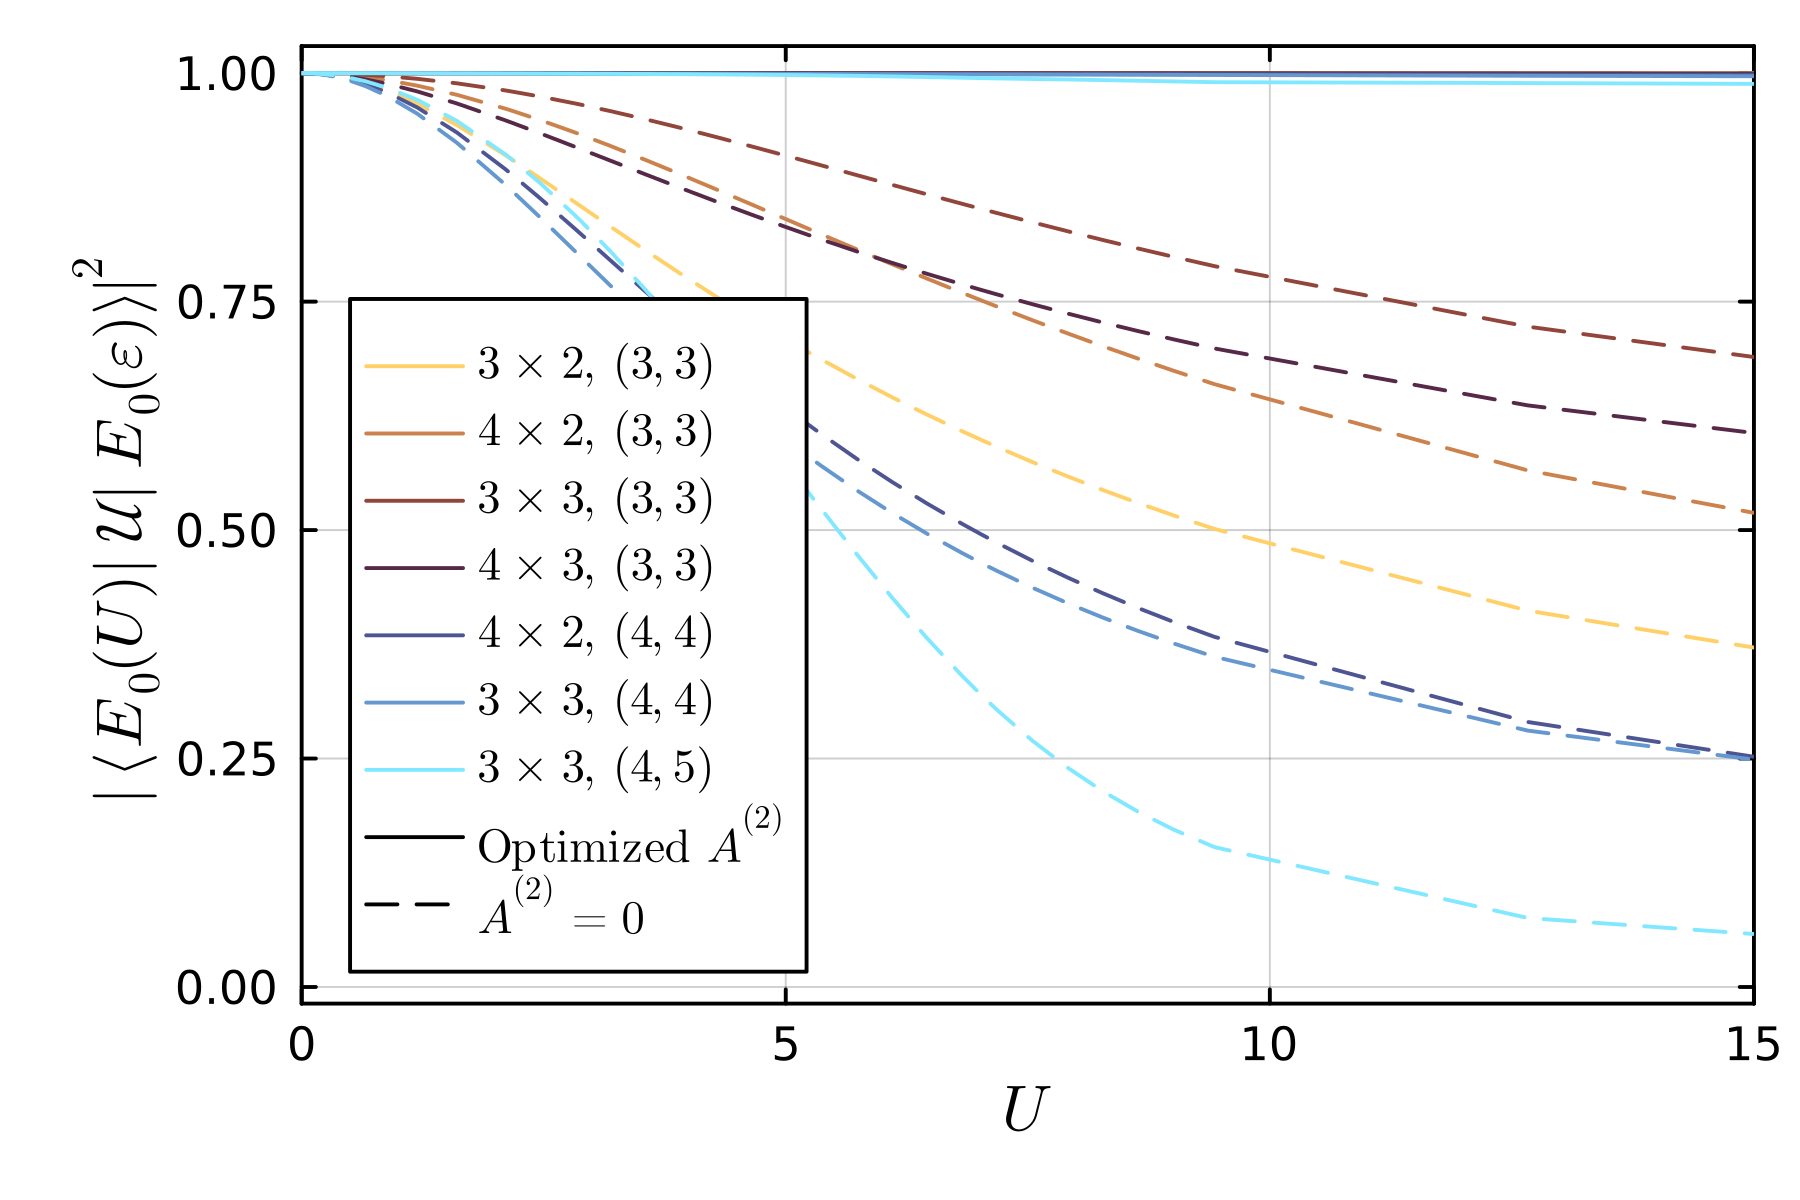

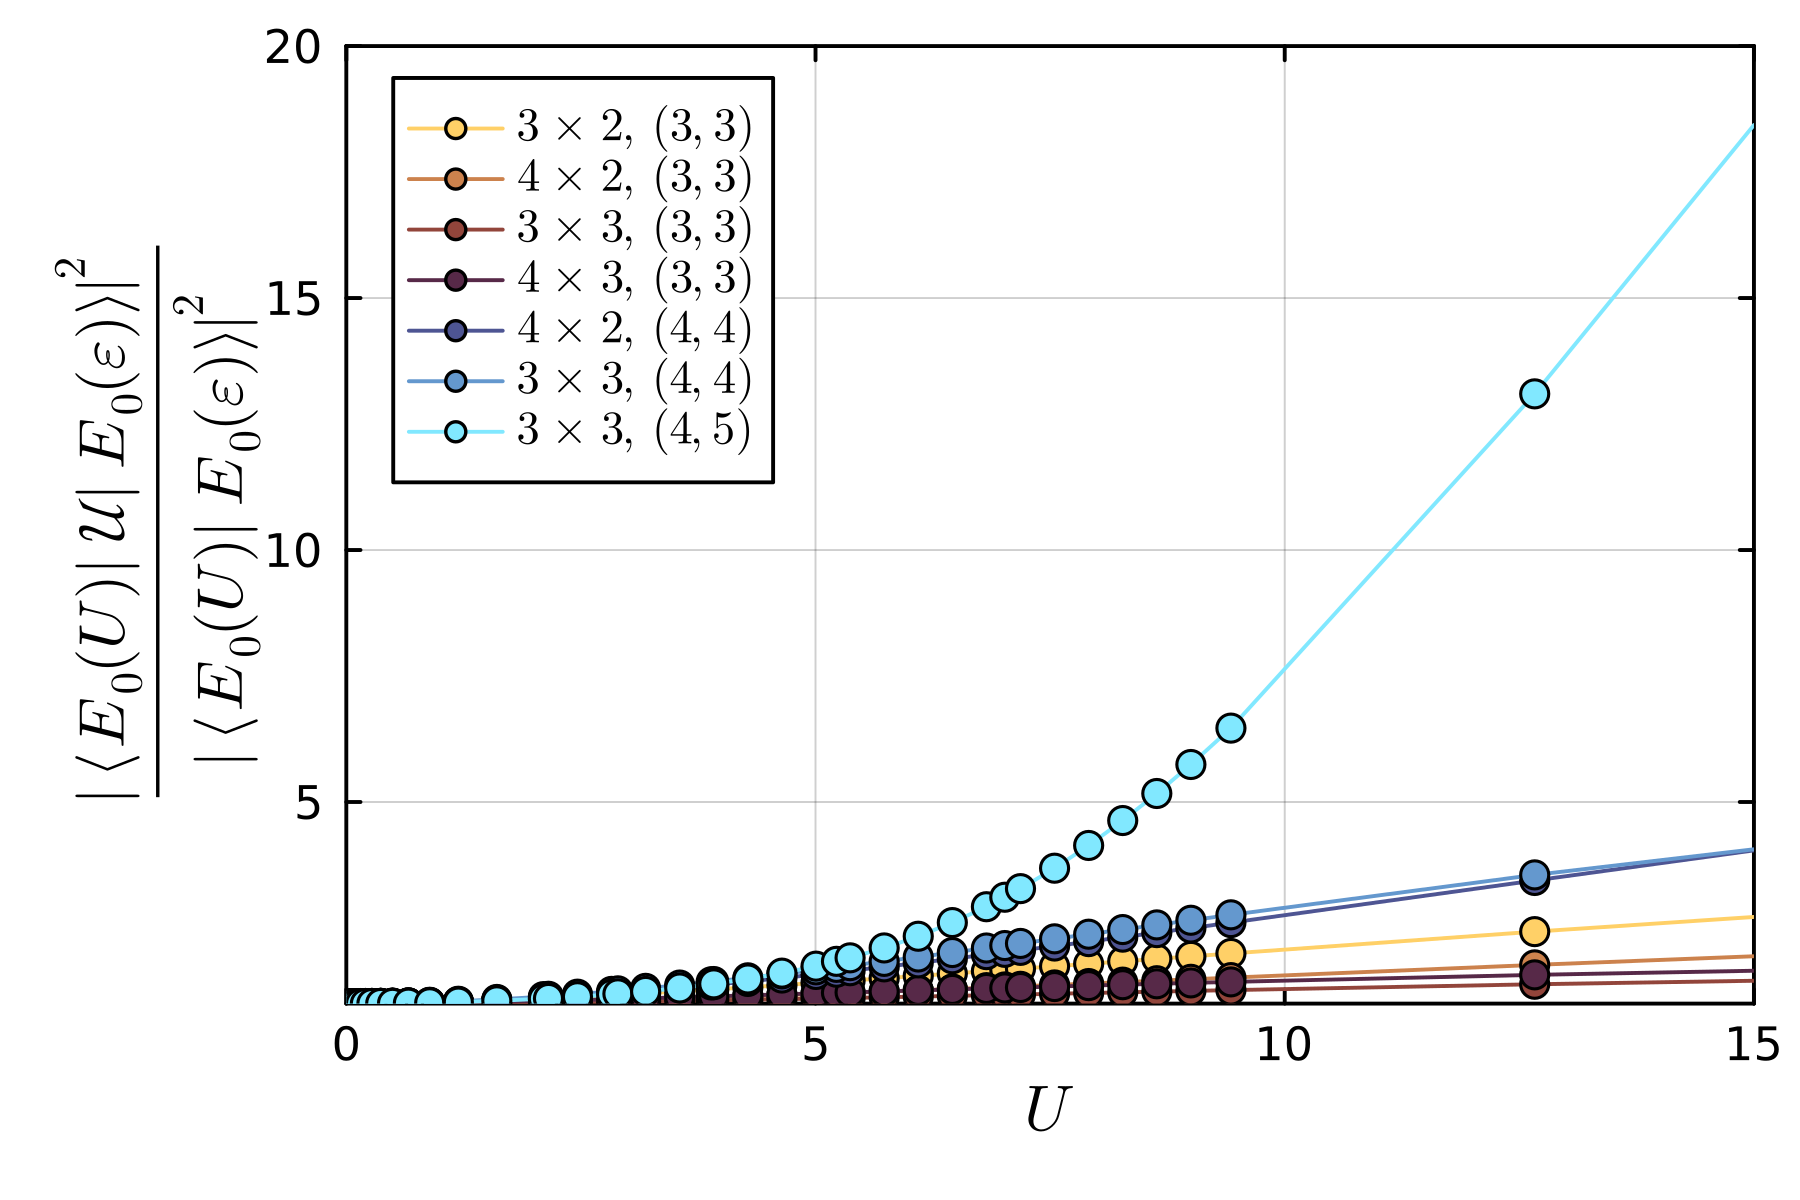

"/home/jek354/research/ML-signproblem/experimenting/ed/good_images/extras/loss_improvement2.pdf"

In [ ]:
# p = plot(dpi=300, xlim=(0,10),ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", xlabel=L"U", legend=:bottomright,
#     yticks=10. .^(-10:0),
#     yscale=:log10,
# )
# plot!(p, interaction_data, initial_loss, linewidth=1, label=L"\mathcal{U}=I")
# plot!(p, interaction_data, loss1,linewidth=1,  label=L"\textrm{Optimized }\;\;\mathcal{U}(A^{(1)},A^{(2)})")
# savefig(p, "good_images/loss_curve_$(file_label)_nonlogscale.png")
# savefig(p, "good_images/loss_curve_$(file_label)_nonlogscale.pdf")
# display(p)
# plot!(interaction_data, loss2, label=L"(n=2)+(n=1)")
# default(fontfamily="Times Roman")


p = plot(dpi=300, xlim=(0,15),ylabel=L"|\langle E_0(U)|\mathcal{U}|E_0(\epsilon)\rangle|^2", xlabel=L"U", legend=:bottomleft,
    framestyle=:box,
    thickness_scaling=1.3,
    # yticks=10. .^(-10:0),
    # yscale=:log10,
)
p_subplot = plot(dpi=300, 
    xlim=(0,15),
    # ylim=(1, 10. .^(4.5)), 
    # ylim=(1, 20),
    ylim=(1,15),
    # ylabel=L"\frac{1-|\langle E_0(U)|E_0(0)\rangle|^2}{1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2}",
    ylabel=L"\frac{|\langle E_0(U)|\mathcal{U}|E_0(\epsilon)\rangle|^2}{|\langle E_0(U)|E_0(\epsilon)\rangle|^2}",
    xlabel=L"U", 
    legend=:topleft,
    framestyle=:box,
    thickness_scaling=1.3,
    # yticks=10. .^(-10:5),
    # yscale=:log10,
    legend_columns=1,
)

hs_sizes = []
final_performance = []
num_tuning_parameters = []

all_u_idcs = 2:60
for (k,(label,file_label, electrons)) in enumerate(file_label_pair)
    coefficient_data = []

    if isfile(joinpath(folder, "$(file_label)/meta_data_and_E.jld2"))
        d = load(joinpath(folder, "$(file_label)/meta_data_and_E.jld2"))["dict"]
        hilbert_space_size = size(d["all_full_eig_vecs"][1],2)
        interaction_data = d["meta_data"]["U_values"]
    else
        valid_files = [f for f in readdir(joinpath(folder, file_label)) if occursin("HubbardED", f)]
        interaction_data = nothing
        hilbert_space_size = nothing
        h5open(joinpath(folder, file_label,valid_files[1]), "r") do data
            interaction_data = read(data["data/uvec"])
            hilbert_space_size = length(read(data["data/evecs/0"])[:,1,1])
        end
    end
    # println(line_width)

    loss1 = []
    loss2 = []
    initial_loss = [] 
    for i = all_u_idcs#2:61
        dic = load_saved_dict(joinpath(folder,file_label, "unitary_map_energy_symmetry=false_N=$(electrons)_u_$i.jld2"))
        # display(dic["metrics"])
        push!(coefficient_data, dic["coefficients"][2])
        push!(loss1, 1 - dic["metrics"]["loss"][2])
        if length(dic["metrics"]["loss"]) > 2
            push!(loss2, 1- dic["metrics"]["loss"][3])
        end
        push!(initial_loss, 1- dic["metrics"]["loss"][1])
    end
    coefficient_data = reduce(hcat, coefficient_data)

    selected_u_idx = [20,30,45]
    p3 = plot(interaction_data[all_u_idcs], coefficient_data', ylim=(-0.5,0.5),alpha=0.06, 
            xlim=(0,10),label=nothing, xlabel=L"U", ylabel=L"A^{(2)} \;\textrm{value}", color=:royalblue1,
            thickness_scaling = 1.5)
    for (c_idx, u_idx) in enumerate(selected_u_idx)
        vline!(p3, [interaction_data[u_idx]], linestyle=:dash, color=cmap[c_idx], label=L"U=%$(round(interaction_data[u_idx],digits=2))")
    end 
    # savefig(p3, "good_images/extras/coefficient_curve_$(file_label).png")
    # savefig(p3, "good_images/extras/coefficient_curve_$(file_label).pdf")
    # display(p3)

    plot!(p, interaction_data[all_u_idcs], initial_loss, linewidth=1,label=nothing,color=cmap[k], linestyle=:dash)
    plot!(p, interaction_data[all_u_idcs], loss1, linewidth=1, label=label, color=cmap[k])

    # loss_improvement = (1 .-initial_loss)./  (1 .-loss1)
    loss_improvement = loss1./initial_loss
    target_U_for_plot = 10
    plot!(p_subplot, interaction_data[all_u_idcs],loss_improvement , label=label, color=cmap[k], marker=:circle)
    push!(final_performance, loss_improvement[argmin(abs.(interaction_data .- target_U_for_plot)) + all_u_idcs[1] - 1])
    push!(hs_sizes, hilbert_space_size)
    # use regex to collect the two integers from the string of the form .3x4.
    regex = r"(?<N>\d+)[xX](?<M>\d+)"
    m = match(regex, file_label)
    push!(num_tuning_parameters, get_num_2nd_order_coef(parse(Int, m[:N]), parse(Int, m[:M])))



    for (c_idx, i) in enumerate(selected_u_idx)
        dic = load_saved_dict(joinpath("data",file_label, "unitary_map_energy_symmetry=false_N=$(electrons)_u_$i.jld2"))
        
        p2 = histogram(xlim=(-0.5,0.5),bins=LinRange(-0.5,0.5,50),dic["coefficients"][2],  
            xlabel=L"A^{(2)}\;\textrm{value}", ylabel=L"\textrm{Count}",framestyle=:box,
        thickness_scaling = 2, label=L"U=%$(round(interaction_data[i],digits=2))",
        color=cmap[c_idx])
        # display(p)
        # savefig(p2, "good_images/extras/U=$(round(interaction_data[i],digits=2))_$(file_label)_histogram.png")
        # savefig(p2, "good_images/extras/U=$(round(interaction_data[i],digits=2))_$(file_label)_histogram.pdf")
    end
end


plot!(p, [NaN], [NaN];
    alpha=1,
    lw=1,
    color=:black,
    linestyle=:solid,
    label=L"\textrm{Optimized}\;\,A^{(2)} ",
)

plot!(p, [NaN], [NaN];
    alpha=1,
    lw=1,
    color=:black,
    linestyle=:dash,
    label=L"A^{(2)}=0",
)

display(p)
display(p_subplot)
# display(performance_scaling_plot)
# savefig(p,"good_images/extras/relative_loss.png")
# savefig(p,"good_images/extras/relative_loss.pdf")

savefig(p_subplot,"good_images/extras/loss_improvement2.png")
savefig(p_subplot,"good_images/extras/loss_improvement2.pdf")







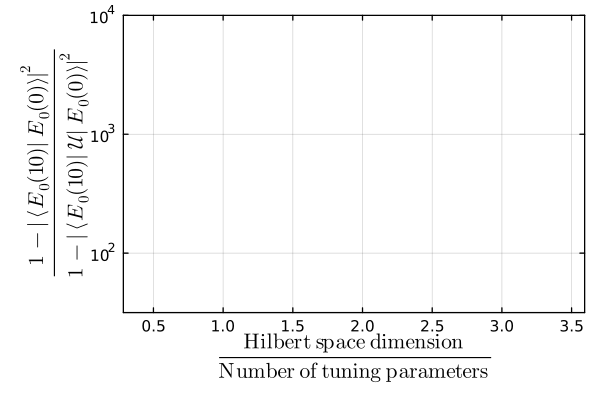

In [8]:

performance_scaling_plot = plot(
    xlabel=L"\frac{\textrm{Hilbert\; space\; dimension}}{\textrm{Number\; of \;tuning \;parameters}}", 
    ylabel=L"\frac{1-|\langle E_0(10)|E_0(0)\rangle|^2}{1-|\langle E_0(10)|\mathcal{U}|E_0(0)\rangle|^2}",
    thickness_scaling=1.3,ylim=(10. .^1.5,1e4), yticks=10. .^(-5:5),
    framestyle=:box, legend=nothing)

scatter!(performance_scaling_plot, hs_sizes ./ num_tuning_parameters, final_performance, yscale=:log10)
# savefig(performance_scaling_plot, "good_images/extras/performance_scaling.pdf")
# savefig(performance_scaling_plot, "good_images/extras/performance_scaling.png")

In [21]:
hs_sizes ./ num_tuning_parameters

7-element Vector{Float64}:
 0.37777777777777777
 0.9423076923076923
 1.5714285714285714
 2.9502923976608186
 1.5096153846153846
 3.5
 3.5

In [ ]:
p = plot(yscale=:log10, dpi=300, xscale=:log10, ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", xlabel=L"U", yticks=10.0 .^(-10:0), xticks=10.0 .^(-3:3), legend=:topleft)
plot!(p, interaction_data, initial_loss, label=L"\mathcal{U}=I")
plot!(p, interaction_data, loss1, label=L"\textrm{Optimized }\;\;\mathcal{U}(A^{(1)},A^{(2)})")
savefig(p, "good_images/extras/loss_curve_$(file_label).png")
savefig(p, "good_images/extras/loss_curve_$(file_label).pdf")
display(p)
# plot!(interaction_data, loss2, label=L"(n=2)+(n=1)")


In [ ]:
# u_data["coefficient_values"][2]

using Plots
using LaTeXStrings


order = 2
x = []
y = []
z = []
z1 = []
z2 = []
target_spin = 3 .-[1,2,1,2]
selected_coefficient_index = falses(length(shared_data["coefficient_labels"][2])) # to filter spins
for i in eachindex(if shared_data["coefficient_labels"][order] !== nothing shared_data["coefficient_labels"][order] else [] end)
    # k1 + k2 -> k1' + k2'
    if !all(shared_data["coefficient_labels"][2][i][term][2] == target_spin[term] for term in 1:4)
        continue
    end
    # display(shared_data["coefficient_labels"][2][i])
    s = sum(abs2, (collect((shared_data["coefficient_labels"][2][i][1][1] +  shared_data["coefficient_labels"][2][i][2][1]).coordinates) .- 2)) # (k1 + k2)^2
    t = sum(abs2, (shared_data["coefficient_labels"][2][i][1][1] -  shared_data["coefficient_labels"][2][i][1+order][1]).coordinates) # (k1 - k1')^2
    u = sum(abs2, (shared_data["coefficient_labels"][2][i][1][1] -  shared_data["coefficient_labels"][2][i][2+order][1]).coordinates) # (k1 - k2')^2
    # println("($s, $t, $u): $(u_data["coefficient_values"][2][i])")

    # push!(x, (u -t)+(rand()*2-1)*0.2)
    push!(x, s)
    push!(y, t)
    push!(z, u)
    # push!(y, s+(rand()*2-1)*0.2)
    selected_coefficient_index[i] = true

end


# scatter(x,y,z, marker_z=coefficient_data[selected_coefficient_index, 1], color=:balance,xlabel=L"s", ylabel=L"t", zlabel="u")

high_range_mask = abs.(coefficient_data[:, 50]) .> 0.2
mid_range_mask = 0.05 .< abs.(coefficient_data[:, 50]) .< 0.2
low_range_mask = abs.(coefficient_data[:, 50]) .< 0.05
# histogram(abs.(coefficient_data[selected_coefficient_index, 50]), bins=30)

for i in eachindex(selected_coefficient_index)
    if !selected_coefficient_index[i] || !high_range_mask[i] 
        continue
    end
    display(shared_data["coefficient_labels"][2][i])
end

In [ ]:
# u_data["coefficient_values"][2]

using Plots
using LaTeXStrings


order = 2
u_index = 50
spins = [[1,1,1,1], [2,2,2,2], [1,2,1,2], [2,1,2,1], [1,2,2,1], [2,1,1,2]]
y_coords = [1,2,1,2]
collected_values = zeros(length(spins), 3,3,3)
for (spin_i, target_spin) in enumerate(spins)
    kx_values = []
    selected_coefficient_index = falses(length(shared_data["coefficient_labels"][2])) # to filter spins
    for i in eachindex(if shared_data["coefficient_labels"][order] !== nothing shared_data["coefficient_labels"][order] else [] end)
        # k1 + k2 -> k1' + k2'
        # constrain that it's the target spin
        if !all(shared_data["coefficient_labels"][2][i][term][2] == target_spin[term] for term in 1:4)
            continue
        end

        # constrain ky==0 (slice)
        if !all(shared_data["coefficient_labels"][2][i][term][1].coordinates[2] == y_coords[term] for term in 1:4)
            continue
            
        end

        push!(kx_values, [])
        for j=1:4
            push!(kx_values[end], shared_data["coefficient_labels"][2][i][j][1].coordinates[1]-1)
        end

        selected_coefficient_index[i] = true

        # collect colelcted_values to plot
        _i,_j,_k,_l = kx_values[end] .+ 1
        for swap1 in [1, -1]
            for swap2 in [1, -1]
                first_two = swap1 == 1 ? [_i,_j] : [_j,_i]
                last_two = swap2 == 1 ? [_k,_l] : [_l,_k]
                if (first_two[1] == first_two[2] && swap1 == -1) || (last_two[1] == last_two[2] && swap2 == -1)
                    continue
                end
                collected_values[spin_i,first_two...,last_two[1]] = swap1*swap2*coefficient_data[i, u_index]
            end
        end 
    end


    # scatter(x,y,z, marker_z=coefficient_data[selected_coefficient_index, 1], color=:balance,xlabel=L"s", ylabel=L"t", zlabel="u")
    # println(sum(selected_coefficient_in≥dex))
    for i in eachindex(kx_values)
        tmp_ycoords = y_coords .- 1
        dd = kx_values[i][1] == kx_values[i][3] && tmp_ycoords[1] == tmp_ycoords[3] && kx_values[i][2] == kx_values[i][4] && tmp_ycoords[2] == tmp_ycoords[4]
        onsite = (kx_values[i][1] == kx_values[i][3] == kx_values[i][2] == kx_values[i][4]) && (tmp_ycoords[1]  == tmp_ycoords[2] == tmp_ycoords[3]  == tmp_ycoords[4])
            pairing = (kx_values[i][1] == kx_values[i][2] && tmp_ycoords[1] == tmp_ycoords[2]) && (kx_values[i][3] == kx_values[i][4] && tmp_ycoords[3] == tmp_ycoords[4])
        double_to_split = ((kx_values[i][1] == kx_values[i][2] && tmp_ycoords[1] == tmp_ycoords[2]) || (kx_values[i][3] == kx_values[i][4] && tmp_ycoords[3] == tmp_ycoords[4])) && !dd && !pairing
        label = begin 
            if dd 
                spin_flip = !(target_spin[1] == target_spin[3] && target_spin[2] == target_spin[4])
                "dd($(abs(kx_values[i][1] - kx_values[i][2])),$(abs(tmp_ycoords[1] - tmp_ycoords[2]))) " * (spin_flip ? "spin_flip " : "")  
            else 
                "" 
            end * 
            if onsite
                "onsite " 
            else 
                "" 
            end * 
            if pairing 
                "pairing " 
            else 
                "" 
            end * 
            if double_to_split 
                "double_to_split" 
            else 
                "" 
            end
        end
        println("$target_spin $(kx_values[i]) $(coefficient_data[selected_coefficient_index, :][i, u_index]) $(label)")
    end
end


In [ ]:
using Plots.Measures: mm
p = []
for j=1:6
for i=1:3
    push!(p,heatmap(collected_values[j, :,:,i],c=:balance, yticks=[1,2,3], xticks=[1,2,3], clims=(-0.4,0.4),xlabel=L"k^x_1",ylabel=L"k^x_2", title=L"A^{(2)}_{\mathbf{k}_1\mathbf{k}_2\mathbf{k}_3\mathbf{k}_4}c^\dagger_{\mathbf{k}_1}c^\dagger_{\mathbf{k}_2}c_{\mathbf{k}_3}c_{\mathbf{k}_4},\quad k^x_3=%$i \;%$(spins[j])" ))
end
end
plot(p...,layout=(6,3),size=(1200,2000),link=:y, top_margin=0mm,bottom_margin=0mm,left_margin=0mm,right_margin=-5mm)
savefig("coefficients")

In [ ]:
using StatsBase

data = coefficient_data[:,1:53]'
nbins  = 40
lo, hi = minimum(data), maximum(data)
edges  = range(lo, hi, length = nbins + 1)

# 2. Build the counts matrix: (nbins × n_cols)
n_cols = size(data, 1)
counts = zeros(Int, nbins, n_cols)

for i in 1:n_cols
    h = fit(Histogram, data[i, :], edges)
    counts[:, i] = h.weights
end

# 3. Bin centers for the y-axis
bin_centers = (edges[1:end-1] .+ edges[2:end]) ./ 2

# 4. Plot heatmap
#    x → column index (1:n_cols)
#    y → bin centers
#    z → counts matrix
p = heatmap(
    interaction_data[1:53],
    bin_centers,
    counts,
    xlabel = L"U",
    ylabel = L"A^{(2)}\;\textrm{value\;\,count}",
    color  = :hot,
    xlim=(0,10),
)
savefig(p,"good_images/histogram_$(file_label).pdf")
savefig(p,"good_images/histogram_$(file_label).png")
display(p)

In [ ]:
# pruning study
# folder = "/media/jonathon/Jonathon HDD/datasets/HubbardED/N=3" #
folder = raw"C:\Users\jonat\Downloads\N=3"
energy_meta_data_dict = load_saved_dict(joinpath(folder,"meta_data_and_E.jld2"))
degen_rm_U = energy_meta_data_dict["degen_rm_U"]
H = energy_meta_data_dict["H"]
U_values = energy_meta_data_dict["meta_data"]["U_values"]
data = merge_jld2_folder(folder; 
    include_keys=["coefficients", "coefficient_labels", "labels", "all_matrices"], 
    file_filter=[dic -> dic["labels"][1]["starting state"]["level"] == 58 && dic["labels"][1]["ending state"]["level"] == 58],
    verbose=true)

thresholds = 10.0 .^(-10:0.3:0)
# error_data = zeros(length(thresholds), length(U_values))
# original_error_data = zeros(length(U_values))
removed_terms = zeros(length(thresholds), length(U_values))

for k in eachindex(data["coefficients"])
    starting_U_level = data["labels"][1]["starting state"]["level"]
    starting_U_index = data["labels"][1]["starting state"]["U index"]
    ending_U_level = data["labels"][k]["ending state"]["level"]
    ending_U_index = data["labels"][k]["ending state"]["U index"]

    mat_accurate = Matrix(sum(data["all_matrices"][k]))
    found_u_index = data["labels"][k]["ending state"]["U index"]
    n1_overlap_true = energy_meta_data_dict["degen_rm_U"][ending_U_index][:,ending_U_level]' * exp(1im*mat_accurate) * energy_meta_data_dict["degen_rm_U"][starting_U_index][:,starting_U_level]
    # original_error_data[found_u_index] = 1-abs2(n1_overlap_true)
    for (l,threshold) in enumerate(thresholds)
        println("($l,$k) of ($(length(thresholds)), $(length(U_values)))")
        
        removed_terms[l,found_u_index] = sum(sum(abs.(data["coefficients"][k][i]) .< threshold) for i=1:2)
        # println(sum(sum(abs.(data_dict_tmp["coefficients"][1][i]) .< 1e-3) for i=1:2)/sum())

        # n1_overlap = energy_meta_data_dict["degen_rm_U"][ending_U_index][:,ending_U_level]' * exp(1im*mat) * energy_meta_data_dict["degen_rm_U"][starting_U_index][:,starting_U_level]
        # # println(found_u_index)
        # error_data[l,found_u_index]  = 1-abs2(n1_overlap)
    end
end



In [ ]:
electrons = (3,3)
file_label = "N=$(electrons)_3x2"
folder = "data/$(file_label)_3"

folder = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/pruning_analysis.jld2"
d = load(folder)

#pruning analysis
cmap = cgrad(:jet1, 30, categorical=false)
p = plot( xlabel="fraction of parameters removed with truncation", ylabel=ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", colorbar_title=L"\log_{10}(U)", framestyle=:box,
    yticks=10.0 .^ (-20:1:10), yscale=:log10)
# )

for i=9:3:59
    filt = d["removed_terms"][:,i] .> 0

    err = max.(abs.(d["error_data"][:,i][filt]),1e-16)
    rel_err = err ./ err[1]
    # println(d["removed_terms"][:,i])
    # println(d["removed_terms"][:,i][filt])
    plot!(p,d["removed_terms"][:,i][filt]./maximum(d["removed_terms"][:,i][filt]),rel_err, line_z=log10.(repeat([interaction_data[i]],sum(filt))),color=cmap, label=nothing, marker=:circle, markersize=1)
end
display(p)

# #pruning analysis
# cmap = cgrad(:jet1, 30, categorical=false)
# p = plot( xlabel="fraction of parameters removed with truncation", ylabel=ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", colorbar_title=L"\log_{10}(U)", framestyle=:box,
#     yticks=10.0 .^ (-20:3:0), yscale=:log10)
# # )

# p = plot(dpi=200)
# for err in [1e-2]
#     truncation_fraction = []
#     for i=9:59
#         # println(abs.((d["error_data"][1,i] .- d["error_data"][:,i] ) ./ d["error_data"][1,i]) .< 1e-2)
#         j = findlast(abs.((d["error_data"][1,i] .- d["error_data"][:,i] ) ./ d["error_data"][1,i] ).< err)
#         # println(j)
#         push!(truncation_fraction, d["removed_terms"][j,i]./maximum(d["removed_terms"][:,i]))
#     end
#     plot!(p,interaction_data[9:59], truncation_fraction, xlim=(0,10), ylim=(0,0.12),xlabel=L"U", legend=nothing, linewidth=2, ylabel="Truncation fraction to maintain accuracy")
#     savefig(p,"good_images/pruning_analysis_$(file_label).png")
#     savefig(p,"good_images/pruning_analysis_$(file_label).pdf")
# end
# display(p)

# Single U relative error pruning plot

In [ ]:
using LsqFit

p = plot( xlabel="fraction of parameters removed with truncation", 
            # ylabel=L"\frac{\Delta \textrm{loss}}{\textrm{loss}}", 
            ylabel=L"\frac{|\langle E_0(U)|\mathcal{U}(A^{(1)},A^{(2)})|E_0(0)\rangle|^2-|\langle E_0(U)|E_0(0)\rangle|^2}{1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2}", 
            # ylabel=L"|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2",
            colorbar_title=L"\log_{10}(U)", framestyle=:box,
    # yticks=10.0 .^ (-20:1:10), 
    # yscale=:log10,
    legend=:bottomright,dpi=200)
# )

i = 30
println("U=$(interaction_data[i])")
for (label,file_label) in file_label_pair

    folder = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/pruning_analysis.jld2"
    folder2 = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/meta_data_and_E.jld2"
    d = load(folder2)["dict"]
    hilbert_space_size = size(d["all_full_eig_vecs"][1],2)
    line_width = sqrt(hilbert_space_size)/20
    println(line_width)

    d = load(folder)
 
    filt = d["removed_terms"][:,i] .> 0

    err = max.(abs.(d["error_data"][:,i][filt]),1e-16)
    overlap = 1 .- err
    # overlap = overlap/()
    rel_err = (err .- err[1]) ./ err
    # println(d["removed_terms"][:,i])
    # println(d["removed_terms"][:,i][filt])
    x = d["removed_terms"][:,i][filt]./maximum(d["removed_terms"][:,i][filt])
    y = rel_err

    plot!(p,x,y, linewidth=line_width, label=label, marker=:circle, markersize=1)
end
display(p)
# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.png")
# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.pdf")


# Pruning computation with relative error

In [ ]:
using LsqFit
# using Pkg
# Pkg.activate("/home/jek354/research/ML-signproblem")
# Pkg.update()

using Lattices
using LinearAlgebra
using Combinatorics
using SparseArrays
using Plots
import Graphs
using LaTeXStrings
using Statistics
using Random
using Zygote
using Optimization, OptimizationOptimisers
using JSON
using OptimizationOptimJL
using JLD2
using ExponentialUtilities


include("ed_objects.jl")
include("ed_functions.jl")
include("ed_optimization.jl")
include("utility_functions.jl")

softplus(x) = max(x, zero(x)) + log1p(exp(-abs(x)))
model(x,p) = @. (1/p[1]*softplus(p[1]*(p[3]*(x-p[2]))) - 1/p[4]*softplus(p[4]*(p[3]*(x-p[5]))))/(p[3]*max(p[5]-p[2],1e-2))
model(x, p) = @. (tanh(p[2]*(x-p[3]))+1)/2

electrons = (3,3)
file_label = "N=$(electrons)_3x2"
folder = joinpath(@__DIR__, "data", "$(file_label)_3")
# folder="data/tmp"

e_metadata = load_saved_dict(joinpath(folder, "meta_data_and_E.jld2"))
interaction_data = e_metadata["meta_data"]["U_values"]


fit_params = []
u_indices = 15:55

for (label,file_label) in file_label_pair
    push!(fit_params, [])
    for i = u_indices

        folder = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/pruning_analysis.jld2"
        folder2 = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/meta_data_and_E.jld2"
        d = load(folder2)["dict"]
        hilbert_space_size = size(d["all_full_eig_vecs"][1],2)
        line_width = sqrt(hilbert_space_size)/20

        d = load(folder)
        filt = d["removed_terms"][:,i] .> 0

        err = max.(abs.(d["error_data"][:,i][filt]),1e-16)
        overlap = 1 .- err
        rel_err = (err .- err[1]) ./ err
        # println(d["removed_terms"][:,i])
        # println(d["removed_terms"][:,i][filt])
        x = d["removed_terms"][:,i][filt]./maximum(d["removed_terms"][:,i][filt])
        y = rel_err

        prepend!(x,[-0.05, -0.1,-0.2])
        prepend!(y,[0.0,0,0])
        filt2 = y .< 0.45 .|| y .>0.9

        fit = curve_fit(model, x[filt2], y[filt2], [20.0,0.2,1,8,0.7])
        if i == u_indices[1]+12
            println(file_label)
            println("U=$(interaction_data[i])")
            p = plot(x,y)
            plot!(p, LinRange(-0.2,1,200), model(LinRange(-0.2, 1,200),fit.param), label="fit")
            display(p)
        end
        push!(fit_params[end], fit.param)
        
    end
end

# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.png")
# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.pdf")





# Pruning with relative error summary plot

In [ ]:

function find_root_bisection(f, a, b; tol=1e-5, max_iters=100)
    fa = f(a)
    fb = f(b)
    if sign(fa) == sign(fb)
        return NaN
    end
    for _ in 1:max_iters
        c = (a + b) / 2
        fc = f(c)
        if abs(fc) < tol || (b - a) / 2 < tol
            return c
        end
        if sign(fc) == sign(fa)
            a = c
            fa = fc
        else
            b = c
            fb = fc
        end
    end
    return (a + b) / 2
end

threshold = 0.99
x_thresholds = []

p = plot(xlim=(0,10), xlabel=L"U", ylabel=L"\textrm{Max\;sparsity\;at\;threshold\;} |\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2 > %$(threshold)")
for (param_u,(label,file_label)) in zip(fit_params,file_label_pair)

    folder2 = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/meta_data_and_E.jld2"
    d = load(folder2)["dict"]
    hilbert_space_size = size(d["all_full_eig_vecs"][1],2)
    line_width = sqrt(hilbert_space_size)/20

    push!(x_thresholds, Float64[])
    for p in param_u
        # Find x coordinate where model(x, p) is equal to 1 - threshold
        x_val = find_root_bisection(x -> model(x, p) - (1-threshold), -1.0, 2.0)
        push!(x_thresholds[end], x_val)
    end
    plot!(p, interaction_data[u_indices], x_thresholds[end], label=label, linewidth=line_width)
end
savefig("good_images/extras/pruning_data_overlap_softplus_thres=$(threshold).png")
savefig("good_images/extras/pruning_data_overlap_softplus_thres=$(threshold).pdf")
display(p)



# Pruning computation and single $U$ plot

[1.8946361239720115, 1.405296034520717]
ERROR: [99.84004784605429, 99.84004784553666, 99.84004784728727, 99.84004784728727, 99.84004784728727, 99.84004784385246, 99.84004783964176, 99.84004783964176, 99.84004783944151, 99.84004783118704, 99.84004780566548, 99.84004780566548, 99.84004775219115, 99.84004775219115, 99.84004775219115, 99.84004772137122, 99.84004769886545, 99.84004583541675, 99.84004361479846, 99.84003765958973, 99.84002668234264, 99.84002250572637, 99.84002250572637, 99.84002250572637, 99.84002250572637, 99.84002250572637, 99.84002250572637, 99.83865448841384, 99.83865448841384, 99.83865448841384, 99.837479780233, 99.78590402856788, 99.78590402856788, 99.8289167534823, 99.8289167534823, 99.8139430959837, 99.74362658946, 99.7283764427928, 99.69343150440297, 98.07297170007243, 82.29731753637313, 78.54331375028413, 69.42685004798447, 52.8918899558243, 46.69595540719796, 42.001821849745745, 42.00182821519653, 42.00184131682177, 42.00184131682177, 42.00184131682177, 42.00184131

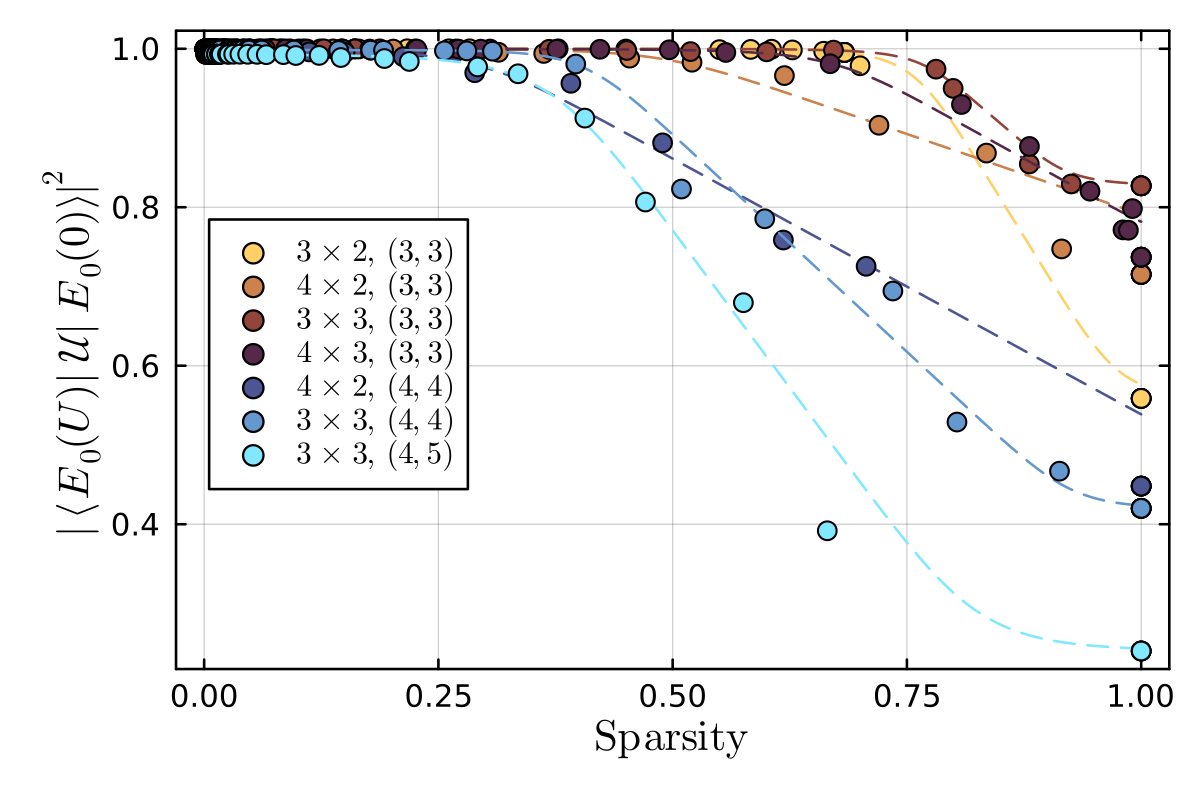

In [8]:

softplus(x,b) = max(x, zero(x)) + log(b) + log1p(exp(-abs(x))/b)
scaled_softplus(x, p1, p2) = 1/log(1+p2)*softplus(p1*x, p2)
model(x,p) = @. 1 - (p[6]*scaled_softplus(p[5]*(x-1), p[1], p[2]) + (1-p[6])*scaled_softplus(p[5]*(x-1), p[3], p[4]))
# model(x,p) = @. (1-tanh(p[1]*(x-p[2])))/2
model(x,p) = @. (1-p[1]*(x-p[2])/(1+abs(p[1]*(x-p[2]))^p[3])^(1/p[3]))/2
println(scaled_softplus.([1,0.5], 1, 1.0))

electrons = (3,3)
file_label = "N=$(electrons)_3x2"
folder = joinpath(@__DIR__, "data", "$(file_label)_3")
# folder="data/tmp"

e_metadata = load_saved_dict(joinpath(folder, "meta_data_and_E.jld2"))
interaction_data = e_metadata["meta_data"]["U_values"]



hilbert_space_sizes = []
fit_params2 = []
rescaling_vals = []
rescale(x,p) = @. x*(p[2]-p[1])+p[1]
u_indices = 15:55

selected_U = 8
pruning_plot_u_idx = argmin(abs.(interaction_data[u_indices] .- selected_U)) + u_indices[1] - 1
pruning_plot = plot(xlabel=L"\textrm{Sparsity}", ylabel=L"|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2",thickness_scaling=1.3, framestyle=:box, dpi=200, legend=:bottomleft)
cmap = palette(:managua, length(file_label_pair))

for (color_i, (label,file_label,_)) in enumerate(file_label_pair)
    push!(fit_params2, [])
    push!(rescaling_vals, [])
    
    for i = u_indices

        # if i != 25
        #     continue
        # end
        folder = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/pruning_analysis.jld2"
        folder2 = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/meta_data_and_E.jld2"
        d = load(folder2)["dict"]
        hilbert_space_size = size(d["all_full_eig_vecs"][1],2)
        line_width = sqrt(hilbert_space_size)/20
        if i == u_indices[1]
            push!(hilbert_space_sizes, hilbert_space_size)
        end 
        d = load(folder)
        filt = d["removed_terms"][:,i] .> 0
        if abs(interaction_data[i] - 8)< 0.1 && file_label == "N=(4, 4)_3x3_2"
            println("ERROR: $((1 .- abs.(d["error_data"][:,i][filt])).*100)")
        end

        err = max.(abs.(d["error_data"][:,i][filt]),1e-16)
        overlap = 1 .- err

        # if overlap[1] < 0.99
        #     println(file_label)
        #     display(d["error_data"][:,i][filt])
        #     error("bad overlap: $(overlap[1])")
        # end

        # rel_err = (err .- err[1]) ./ err
        # println(d["removed_terms"][:,i])
        # println(d["removed_terms"][:,i][filt])
        x = d["removed_terms"][:,i][filt]./maximum(d["removed_terms"][:,i][filt])
        y = (overlap .- overlap[end])./(overlap[1] .- overlap[end])
        push!(rescaling_vals[end], [overlap[end],overlap[1]])

        filt2 = y .>= y[end] 

        weight = 1 ./(1 .-overlap).^2
        # println(weight)
        fit = nothing
        # for iter in 1:4
        #     # Fit the model using the current inliers
        #     fit = curve_fit(model, x[filt2], y[filt2], weight[filt2], [1.0, 1.0, 1.0, 1.0, 1.0, 0.5])
            
        #     # Calculate residuals for ALL data points
        #     residuals = abs.(y .- model(x, fit.param))
            
        #     # Use the standard deviation of the current inliers' residuals as a threshold basis
        #     inlier_std = max(std(residuals[filt2]), 1e-8)
            
        #     # Keep points that are within 2.0 standard deviations (to remove noise of later data)
        #     new_filt2 = residuals .<= 5.0 * inlier_std
            
        #     # Stop if the filter has converged
        #     if new_filt2 == filt2
        #         break
        #     end
            
        #     # Safety check to avoid dropping too many points
        #     if sum(new_filt2) < length(fit.param) + 2
        #         break
        #     end
            
        #     filt2 = new_filt2
        # end
        fit = curve_fit(model, x[filt2], y[filt2],  weight[filt2],[1.0, 1.0, 1.0], lower=[-Inf, -Inf, 0.1], upper=[Inf, Inf, 10])
        
        # if i==35#i == 25
        #     p = scatter(x[filt2], 1 .-rescale(y[filt2],rescaling_vals[end][end]), label="inliers", color=:blue, yscale=:log10, legend=:left)#, ylim=(-0.01,1.01)
        #     # p1 = scatter(x[filt2], y[filt2], label="inliers", color=:blue)
        #     # println(1 .-rescaling_funcs[end](y[filt2]))
        #     if any(.!filt2)
        #         scatter!(p, x[.!filt2], 1 .-rescale(model(y[.!filt2],fit.param),rescaling_vals[end][end]), label="outliers", color=:red)
        #     end
        #     plot!(p, LinRange(0,1,200), 1 .- rescale(model(LinRange(0, 1,200),fit.param),rescaling_vals[end][end]), label="fit", color=:black)
        #     # plot!(p1, LinRange(0,1,200), model(LinRange(0, 1,200),fit.param), label="fit", color=:black)
        #     hline!(p, [1-0.9999])
        #     # display(p1)
        #     display(p)ß
        #     # println(rescaling_funcs[end](maximum(y))," ",rescaling_funcs[end](model(0, fit.param)))
        # end
        # println(fit.param)
        push!(fit_params2[end], copy(fit.param))

        if i == pruning_plot_u_idx
            plot!(pruning_plot, LinRange(0,1,200), rescale(model(LinRange(0, 1,200),fit.param),rescaling_vals[end][end]), label=nothing, color=cmap[color_i], linestyle=:dash)
            scatter!(pruning_plot, x[filt2], rescale(y[filt2],rescaling_vals[end][end]), color=cmap[color_i], label=label, legend=:left)
        end
     
    end
    # break
end

# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.png")
# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.pdf")
println("U=$(interaction_data[pruning_plot_u_idx])")
# savefig("good_images/extras/U=$(round(interaction_data[pruning_plot_u_idx], digits=2))_pruning_curve.pdf")
# savefig("good_images/extras/U=$(round(interaction_data[pruning_plot_u_idx], digits=2))_pruning_curve.png")
display(pruning_plot)





# Pruning at threshold overlap plot

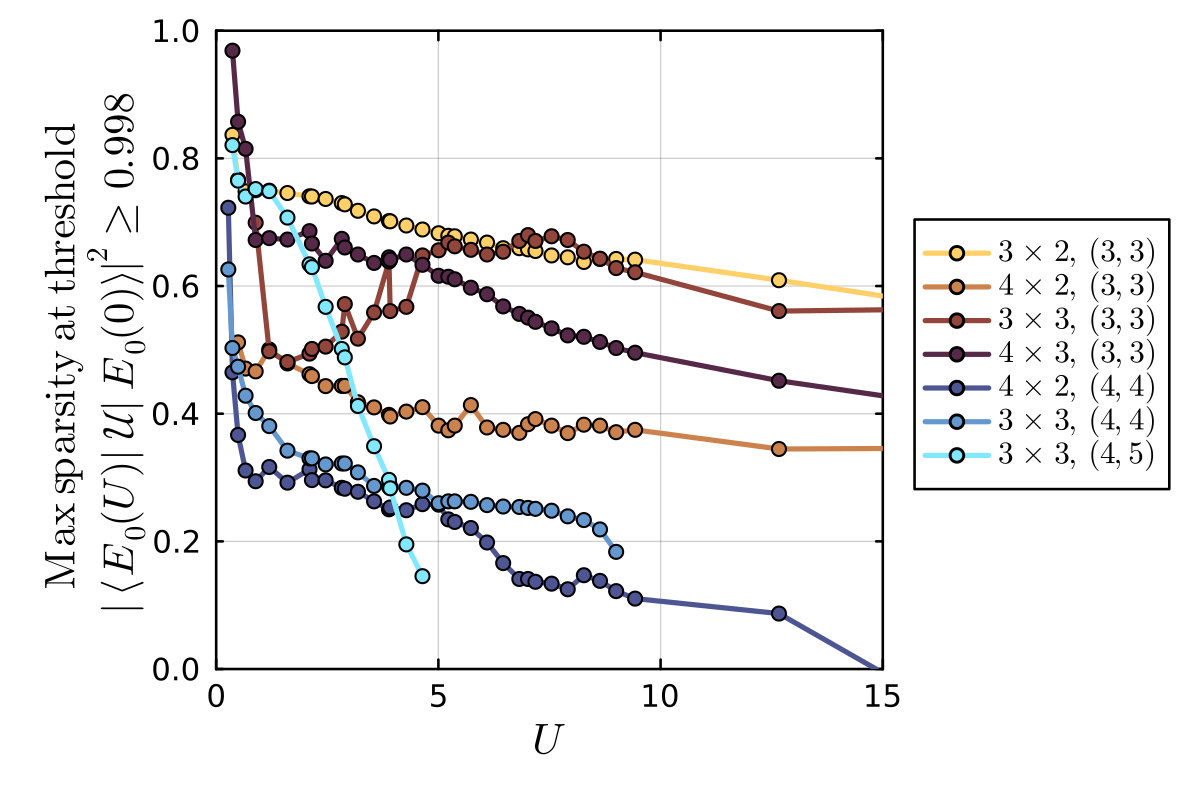

In [ ]:


function find_root_bisection(f, a, b; tol=1e-5, max_iters=100)
    fa = f(a)
    fb = f(b)
    if sign(fa) == sign(fb)
        return NaN
    end
    for _ in 1:max_iters
        c = (a + b) / 2
        fc = f(c)
        if abs(fc) < tol || (b - a) / 2 < tol
            return c
        end
        if sign(fc) == sign(fa)
            a = c
            fa = fc
        else
            b = c
            fb = fc
        end
    end
    return (a + b) / 2
end

threshold = 0.998
x_thresholds = []

p = plot(xlim=(0,15), ylim=(0,1),xlabel=L"U", ylabel=L"\textrm{Max\;sparsity\;at\;threshold\;}"*"\n"*L"|\langle E_0(U)|\mathcal{U}|E_0(\epsilon)\rangle|^2 \geq %$(threshold)", 
    legend=:outerright,#(0.6,0.64),
    # legend=:bottomright,
     thickness_scaling=1.3, framestyle=:box, dpi=200)
for (i,(param_u,(label,file_label,_), rescaling_val, hs_size)) in enumerate(zip(fit_params2,file_label_pair, rescaling_vals, hilbert_space_sizes))

    folder2 = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/meta_data_and_E.jld2"
    line_width = sqrt(hs_size)/20

    push!(x_thresholds, Float64[])
    for (param, rsc_val) in zip(param_u,rescaling_val)

        # tmp = plot(0:0.05:1,1 .- rescale(model(0:0.05:1, param),rsc_val), yscale=:log10)
        # hline!(tmp, [1-threshold])
        # display(tmp)
        x_val = find_root_bisection(x -> rescale(model(x, param),rsc_val) - threshold, -1.0, 2.0)
        push!(x_thresholds[end], x_val)
    end
    plot!(p, interaction_data[u_indices], x_thresholds[end], label=label, 
            linewidth=2, markershape=:circle, c=cmap[i], markersize=3)
end
# savefig("good_images/extras/pruning_data_overlap_ISRU_thres=$(threshold).png")
# savefig("good_images/extras/pruning_data_overlap_ISRU_thres=$(threshold).pdf")
display(p)



# Pruning at "characteristic" sparsity plot

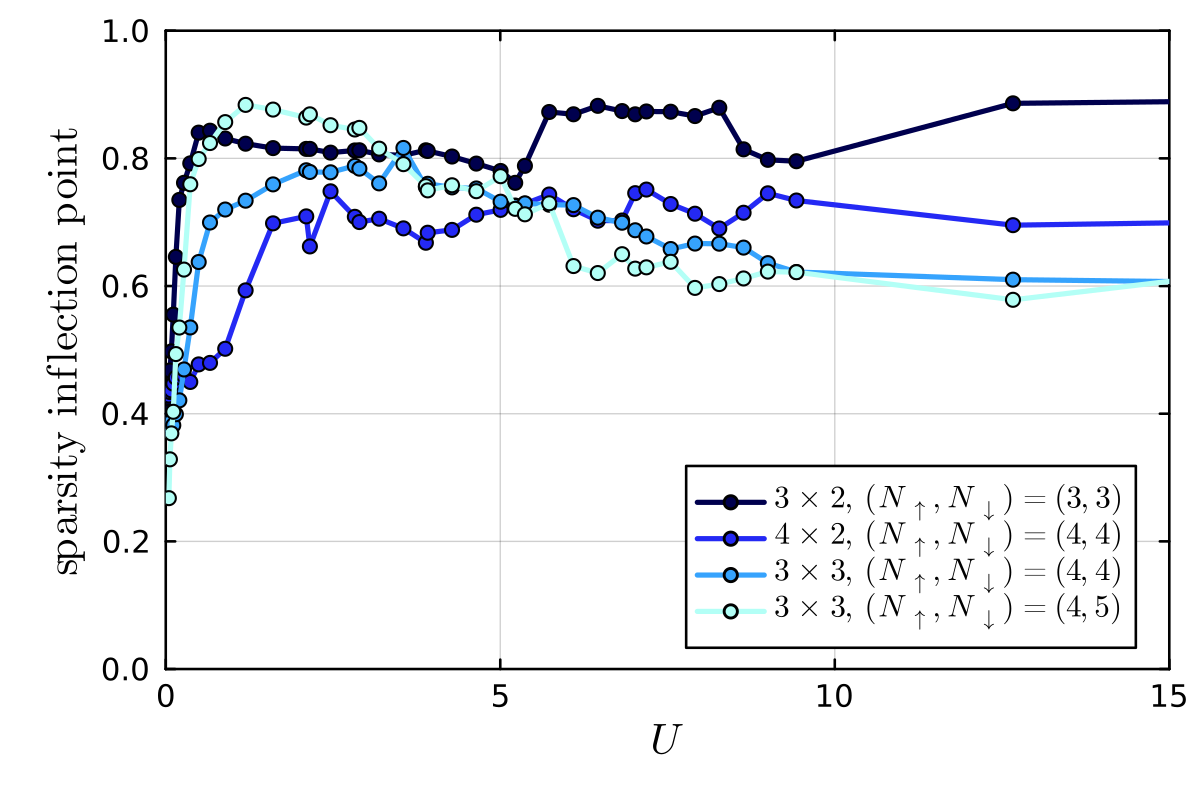

In [20]:
# file_label_pair = [
#     (L"N_\uparrow=3, N_\downarrow=3, 3\times 2","N=(3, 3)_3x2_3"), 
#     # (L"N_\uparrow=3, N_\downarrow=3, 3\times2","N=(3, 3)_3x2_2"),
#     (L"N_\uparrow=4, N_\downarrow=4, 4\times2", "N=(4, 4)_4x2_2"),
#     (L"N_\uparrow=4, N_\downarrow=4, 3\times3", "N=(4, 4)_3x3_2"),
#     (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3_3"),
#     # (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3"),
#     ]


function find_root_bisection(f, a, b; tol=1e-5, max_iters=100)
    fa = f(a)
    fb = f(b)
    if sign(fa) == sign(fb)
        return NaN
    end
    for _ in 1:max_iters
        c = (a + b) / 2
        fc = f(c)
        if abs(fc) < tol || (b - a) / 2 < tol
            return c
        end
        if sign(fc) == sign(fa)
            a = c
            fa = fc
        else
            b = c
            fb = fc
        end
    end
    return (a + b) / 2
end

threshold = 0.99
x_thresholds = []

cmap = palette(:linear_blue_5_95_c73_n256,length(fit_params2))
p = plot(xlim=(0,15), ylim=(0,1),xlabel=L"U", ylabel=L"\textrm{sparsity\;\,inflection\;\,point}", 
    # legend=(0.6,0.64),
    legend=:bottomright,
     thickness_scaling=1.3, framestyle=:box, dpi=200)
for (i,(param_u,(label,file_label,_), rescaling_val, hs_size)) in enumerate(zip(fit_params2,file_label_pair, rescaling_vals, hilbert_space_sizes))

    folder2 = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/meta_data_and_E.jld2"
    line_width = sqrt(hs_size)/20

    push!(x_thresholds, Float64[])
    for (param, rsc_val) in zip(param_u,rescaling_val)

        # tmp = plot(0:0.05:1,1 .- rescale(model(0:0.05:1, param),rsc_val), yscale=:log10)
        # hline!(tmp, [1-threshold])
        # display(tmp)
        push!(x_thresholds[end], param[2])
    end
    plot!(p, interaction_data[u_indices], x_thresholds[end], label=label, 
            linewidth=2, markershape=:circle, c=cmap[i], markersize=3)
end
# savefig("good_images/extras/pruning_data_overlap_ISRU_thres=$(threshold).png")
# savefig("good_images/extras/pruning_data_overlap_ISRU_thres=$(threshold).pdf")
display(p)

